# Part 3: Application to Medical Diagnosis

In this final part, we apply a Convolutional Neural Network (CNN) for the binary classification of breast tumors using the CBIS-DDSM database.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Configuration and Parameters
Here we define the global parameters (training hyperparameters, data paths).

In [2]:
class Config:
    # Paths pointing to the CBIS-DDSM CSV files
    CSV_PATH_TRAIN = "images/archive/csv/mass_case_description_train_set.csv"
    CSV_PATH_TEST = "images/archive/csv/mass_case_description_test_set.csv"
    IMAGE_DIR = "images/archive/" # Root folder containing the 'jpeg' subfolder
    IMAGE_SIZE = 224      # Using 224x224 for ResNet
    BATCH_SIZE = 32
    EPOCHS = 20
    LEARNING_RATE = 1e-4
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
print(f"Device used: {Config.DEVICE}")

Device used: cpu


## 2. Dataset Preparation and Preprocessing

We associate each image with its label from the CSV file.
The `BENIGN` and `BENIGN_WITHOUT_CALLBACK` classes are merged into `0`.
The `MALIGNANT` cases are labeled as `1`.

**Note**: We are using the Kaggle JPEG version of the CBIS-DDSM dataset. The images are stored in subfolders named after their `SeriesInstanceUID`. We extract this UID from the original `.dcm` path in the CSV to find the correct `.jpg` file.

In [3]:
class CBISDDSMDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform
        
        # Mapping classes to binary labels
        self.data['label'] = self.data['pathology'].apply(
            lambda x: 1 if x.strip().upper() == 'MALIGNANT' else 0
        )
        
        self.image_paths = self.data['image file path'].values
        self.labels = self.data['label'].values
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        try:
            # Extract SeriesInstanceUID from the original DICOM path in the CSV
            series_uid = self.image_paths[idx].strip().split('/')[2]
            folder_path = os.path.join(self.image_dir, "jpeg", series_uid)
            
            # Find the actual .jpg file inside the folder
            jpg_files = glob.glob(os.path.join(folder_path, "*.jpg"))
            if len(jpg_files) == 0:
                raise FileNotFoundError(f"No JPG found in {folder_path}")
                
            img_path = jpg_files[0].replace("\\", "/")
            
            # Read the JPG image (ResNet expects 3 channels)
            image = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if image is None:
                raise ValueError(f"cv2 failed to read {img_path}")
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
        except Exception as e:
            # Fallback if image is missing or corrupted (outputs a black square)
            image = np.zeros((Config.IMAGE_SIZE, Config.IMAGE_SIZE, 3), dtype=np.uint8)
            
        if self.transform:
            # PIL Image for torchvision transforms
            pil_img = Image.fromarray(image)
            image_tensor = self.transform(pil_img)
        else:
            image = cv2.resize(image, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
            image = image.astype(np.float32) / 255.0
            # PyTorch dimensions (Channels, H, W)
            image = np.transpose(image, (2, 0, 1))
            image_tensor = torch.tensor(image, dtype=torch.float32)
        
        return image_tensor, torch.tensor(self.labels[idx], dtype=torch.float32)

In [4]:
def show_samples(dataset, num_samples=5):
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    benign_idx = np.where(dataset.labels == 0)[0][:num_samples]
    malign_idx = np.where(dataset.labels == 1)[0][:num_samples]
    
    for i, idx in enumerate(benign_idx):
        img, label = dataset[idx]
        axes[0, i].imshow(img.permute(1, 2, 0).numpy())
        axes[0, i].set_title("Benign (0)")
        axes[0, i].axis('off')
        
    for i, idx in enumerate(malign_idx):
        img, label = dataset[idx]
        axes[1, i].imshow(img.permute(1, 2, 0).numpy())
        axes[1, i].set_title("Malignant (1)", color='red')
        axes[1, i].axis('off')
        
    plt.suptitle("Sample CBIS-DDSM Images (Kaggle JPEG)", fontsize=16)
    plt.tight_layout()
    plt.show()

## 3. Network Architecture (CNN)
A simple CNN comprising convolutional layers followed by MaxPooling, and fully connected classification layers.

In [5]:
class BreastCancerCNN(nn.Module):
    def __init__(self):
        super(BreastCancerCNN, self).__init__()
        # Load pre-trained ResNet18
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Freeze early layers for faster training and to avoid losing extracted features
        for param in list(self.model.parameters()):
            param.requires_grad = True
            
        # Replace the final fully connected layer for binary classification
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 1)
        )
        
    def forward(self, x):
        return self.model(x)

## 4. Training and Evaluation Functions

In [6]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=Config.EPOCHS):
    model.to(Config.DEVICE)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    best_val_loss = float('inf')
    patience_counter = 0
    early_stopping_patience = 6
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(Config.DEVICE), labels.to(Config.DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        
        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(Config.DEVICE), labels.to(Config.DEVICE)
                outputs = model(images).squeeze()
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                
                # Binary prediction with a 0.5 threshold
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = correct / total
        
        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch [{epoch+1:02d}/{epochs}] - Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break
        
    return history

def evaluate_model(model, test_loader):
    model.to(Config.DEVICE)
    model.eval()
    
    all_labels, all_probs, all_images = [], [], []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images_device = images.to(Config.DEVICE)
            outputs = model(images_device).squeeze()
            probs = torch.sigmoid(outputs)
            
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
            all_images.extend(images.numpy())
            
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_images = np.array(all_images)
            
    # Compute ROC curve and find optimal threshold using Youden's J statistic
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    J = tpr - fpr
    best_idx = np.argmax(J)
    best_thresh = thresholds[best_idx]
    
    print("\n==============================")
    print("      THRESHOLD OPTIMIZATION")
    print("==============================")
    print(f"Optimal Decision Threshold : {best_thresh:.4f}")
    
    # Convert probabilities to binary using optimal threshold
    all_preds = (all_probs > best_thresh).astype(float)
    
    # Compute global metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    
    print("\n==============================")
    print("      MODEL PERFORMANCE")
    print("==============================")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print("\n--- Detailed Report ---")
    print(classification_report(all_labels, all_preds, target_names=["Benign (0)", "Malignant (1)"], zero_division=0))
    
    # Generate Confusion Matrix Heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["Benign (0)", "Malignant (1)"], 
                yticklabels=["Benign (0)", "Malignant (1)"])
    plt.xlabel('Model Predictions')
    plt.ylabel('Clinical Reality (True Labels)')
    plt.title(f'Confusion Matrix (Threshold = {best_thresh:.2f})')
    plt.tight_layout()
    plt.show()
    
    return all_labels, all_preds, all_images

## 5. Main Pipeline

Loading the train set and test set separately, relying on the two CSV files.

Loading Train and Test data...


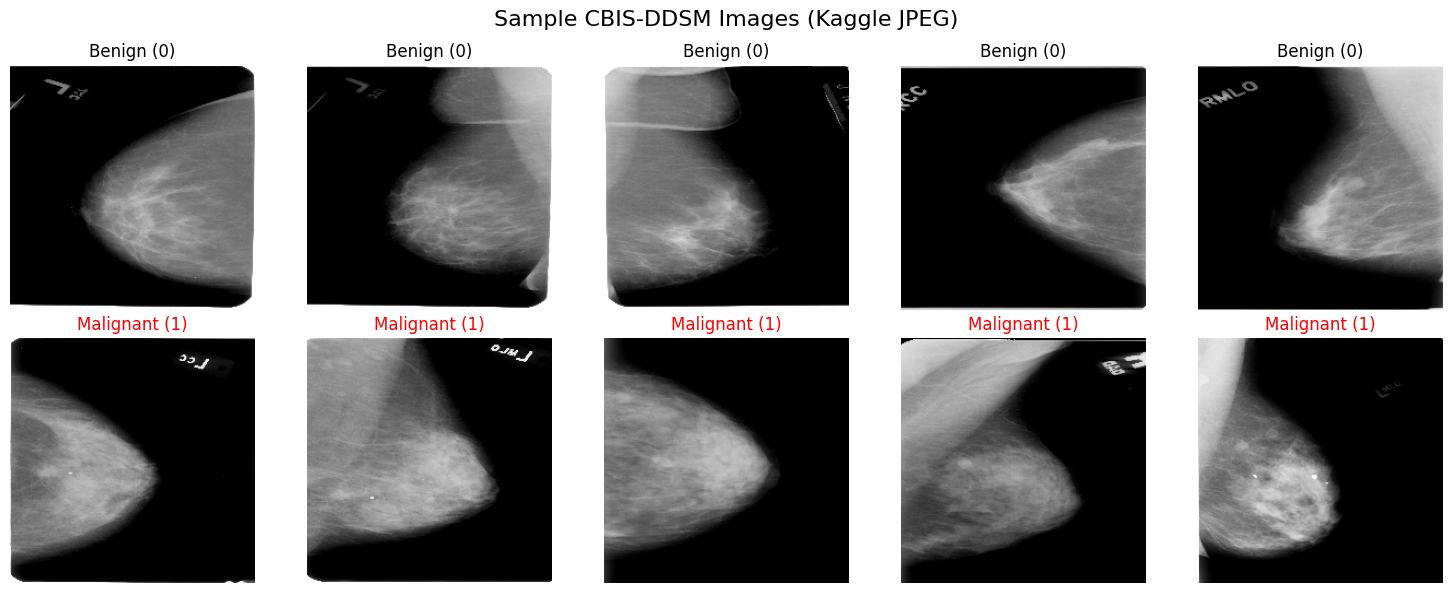

Imbalance detected: 545 Benign vs 509 Malignant.
Corrective weight applied to the 'Malignant' class via pos_weight: 1.07

Starting training...
Epoch [01/20] - Train Loss: 0.7068 | Val Loss: 0.6561 | Val Acc: 0.5871
Epoch [02/20] - Train Loss: 0.4559 | Val Loss: 0.6236 | Val Acc: 0.6970
Epoch [03/20] - Train Loss: 0.2444 | Val Loss: 0.7154 | Val Acc: 0.6970
Epoch [04/20] - Train Loss: 0.1153 | Val Loss: 0.6934 | Val Acc: 0.7424
Epoch [05/20] - Train Loss: 0.0667 | Val Loss: 0.8458 | Val Acc: 0.7159
Epoch [06/20] - Train Loss: 0.0560 | Val Loss: 0.9092 | Val Acc: 0.7159
Epoch [07/20] - Train Loss: 0.0250 | Val Loss: 0.8905 | Val Acc: 0.7424
Epoch [08/20] - Train Loss: 0.0215 | Val Loss: 0.7941 | Val Acc: 0.7500
Early stopping triggered after 8 epochs.

Final evaluation on the Test set...

      THRESHOLD OPTIMIZATION
Optimal Decision Threshold : 0.8064

      MODEL PERFORMANCE
Accuracy  : 0.7407
Precision : 0.7025
Recall    : 0.5782

--- Detailed Report ---
               precision    re

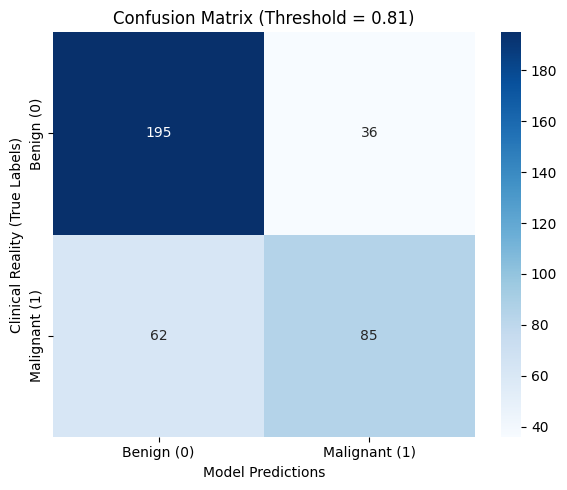

In [7]:
if not os.path.exists(Config.CSV_PATH_TRAIN) or not os.path.exists(Config.CSV_PATH_TEST):
    print(f"[WARNING] CSV files not found. Check paths in Config.")
else:
    print("Loading Train and Test data...")
    train_val_dataset = CBISDDSMDataset(csv_file=Config.CSV_PATH_TRAIN, image_dir=Config.IMAGE_DIR)
    test_dataset = CBISDDSMDataset(csv_file=Config.CSV_PATH_TEST, image_dir=Config.IMAGE_DIR)
    
    # Show a preview of the images once loaded
    show_samples(train_val_dataset)
    
    # Split the Train dataset into Train (80%) and Validation (20%)
    indices = list(range(len(train_val_dataset)))
    train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=train_val_dataset.labels)
    
    train_dataset = torch.utils.data.Subset(train_val_dataset, train_idx)
    val_dataset = torch.utils.data.Subset(train_val_dataset, val_idx)
    
    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)
    
    # --- Class Imbalance Management ---
    train_labels = train_val_dataset.labels[train_idx]
    num_neg = np.sum(train_labels == 0)
    num_pos = np.sum(train_labels == 1)
    
    pos_weight_val = num_neg / num_pos if num_pos > 0 else 1.0
    pos_weight = torch.tensor([pos_weight_val]).to(Config.DEVICE)
    print(f"Imbalance detected: {num_neg} Benign vs {num_pos} Malignant.")
    print(f"Corrective weight applied to the 'Malignant' class via pos_weight: {pos_weight_val:.2f}\n")
    
    # Initialization
    model = BreastCancerCNN()
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=Config.LEARNING_RATE)
    
    # Training and Evaluation
    print("Starting training...")
    history = train_model(model, train_loader, val_loader, criterion, optimizer)
    
    print("\nFinal evaluation on the Test set...")
    y_true, y_pred, test_imgs = evaluate_model(model, test_loader)

## 6. Graphical Visualizations
Here are the learning curves and the visualization of classification errors on the Test set.

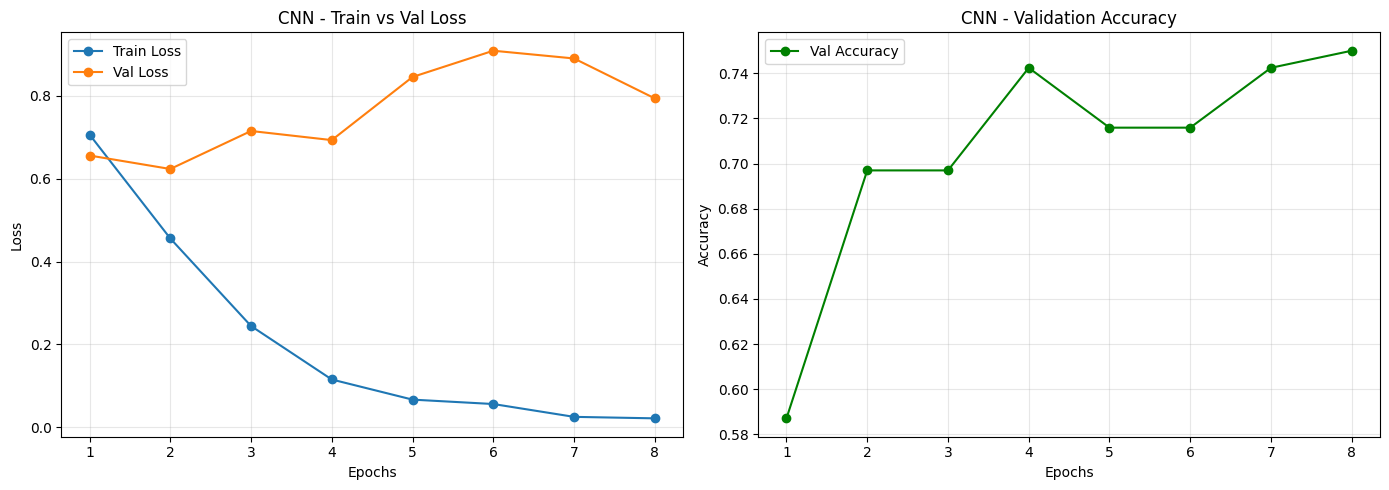


MLP (Breast Cancer CNN) : 98 errors out of 378 tested images.


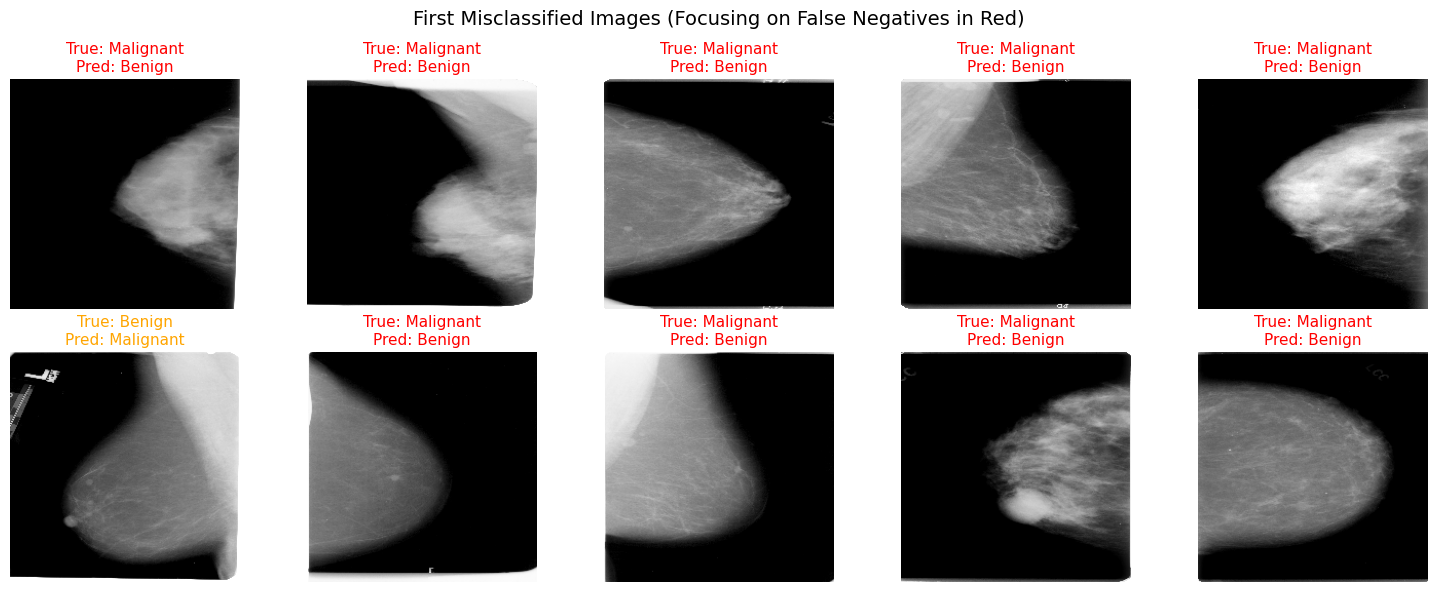

In [8]:
if 'history' in locals() and 'y_pred' in locals() and 'y_true' in locals():
    # =========================================================
    # GRAPH 1: Learning Curves (Loss & Accuracy)
    # =========================================================
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], label='Train Loss', marker='o')
    plt.plot(range(1, len(history['train_loss'])+1), history['val_loss'], label='Val Loss', marker='o')
    plt.title("CNN - Train vs Val Loss")
    plt.xlabel("Epochs"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(history['train_loss'])+1), history['val_acc'], label='Val Accuracy', marker='o', color='green')
    plt.title("CNN - Validation Accuracy")
    plt.xlabel("Epochs"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =========================================================
    # GRAPH 2: Misclassified Images Visualization (Errors)
    # =========================================================
    errors_idx = np.where(y_pred != y_true)[0]
    print(f"\nMLP (Breast Cancer CNN) : {len(errors_idx)} errors out of {len(y_true)} tested images.")
    
    if len(errors_idx) > 0:
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        axes = axes.ravel()
        
        for j, idx in enumerate(errors_idx[:10]): 
            axes[j].imshow(test_imgs[idx][0], cmap='gray')
            
            # Color code: Red = False Negative (very severe), Orange = False Positive
            color = 'red' if y_true[idx] == 1 else 'orange'
            true_lbl = "Malignant" if y_true[idx] == 1 else "Benign"
            pred_lbl = "Malignant" if y_pred[idx] == 1 else "Benign"
            
            axes[j].set_title(f"True: {true_lbl}\nPred: {pred_lbl}", fontsize=11, color=color)
            axes[j].axis('off')
            
        for j in range(len(errors_idx), len(axes)):
            axes[j].axis('off')
            
        plt.suptitle("First Misclassified Images (Focusing on False Negatives in Red)", fontsize=14)
        plt.tight_layout()
        plt.show()
else:
    print("Run the training pipeline (previous cell) to generate the graphs.")